In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge

Academic Integrity and Learning Statement

By submitting my work, I confirm that:

1. The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
2. I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


### Load the data

In [2]:
df = pd.read_csv('train_data.csv')
df.head()

,MW,LogP,NumHDonors,NumHAcceptors,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,pIC50
0,279.273,1.74780,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.000000
1,508.626,4.75440,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.522879
2,317.755,3.45850,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.863279
3,506.606,4.81712,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.040959
4,542.854,5.73340,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000


#### Preparing Features and Target Variables and Checking Their Shapes

In [3]:
X = df.drop('pIC50',  axis=1)
Y = df['pIC50']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (16937, 2052)
Shape of Y: (16937,)


#### Removing low variance features

In [4]:
selection = VarianceThreshold(threshold=(0.02))  
X_var = selection.fit_transform(X)
X_var.shape

(16937, 511)

#### Splliting the data into train and validation (into 80:20)

In [5]:
X_train_us, X_val_us, Y_train_us, Y_val_us = train_test_split(X_var, Y, test_size=0.2, random_state=42)

#### Scalling the data

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_us)
X_val = scaler.transform(X_val_us)

Y_train = Y_train_us
Y_val = Y_val_us

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)

Shape of X_train: (13549, 511)
Shape of X_val: (3388, 511)


### Baseline Model

Calculating Baseline ( Here, I am using mean baseline because by predicting the mean of the target variable (bioactivity) for all samples. I've chosen the mean over the medain. This approach provides a reference point to evaluate the performance of more complex models. Because the mean is a better choice when the target variable (pIC50) has a roughly symmetric or normally distributed range of values.)


In [7]:
def MSE(y, y_pred):
    return np.mean((y - y_pred) ** 2)  

y_train_mean = np.mean(Y_train)

baseline_mse_val = MSE(Y_val, y_train_mean)
baseline_mse_train = MSE(Y_train, y_train_mean)

baseline_rmse_train = np.sqrt(baseline_mse_train)
baseline_rmse_val = np.sqrt(baseline_mse_val)

baseline_r2_train = r2_score(Y_train, np.full_like(Y_train, y_train_mean))
baseline_r2_val = r2_score(Y_val, np.full_like(Y_val, y_train_mean))

print(f"Baseline Model Performance: ")

print(f"Training MSE: {baseline_mse_train}")
print(f"Validation MSE: {baseline_mse_val}")

print(f"Training RMSE: {baseline_rmse_train}")
print(f"Validation RMSE: {baseline_rmse_val}")


Baseline Model Performance: 
Training MSE: 1.9868677557022454
Validation MSE: 2.0222983322473933
Training RMSE: 1.409562966206989
Validation RMSE: 1.4220753609592542


### Linear Regression

Here, train a Linear Regression model and evaluates its performance using MSE, RMSE, and R² on both training and validation datasets.

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)

lr_train_mse = mean_squared_error(Y_train, y_train_pred)
lr_val_mse = mean_squared_error(Y_val, y_val_pred)

lr_train_rmse = np.sqrt(lr_train_mse)
lr_val_rmse = np.sqrt(lr_val_mse)

lr_train_r2 = r2_score(Y_train, y_train_pred)
lr_val_r2 = r2_score(Y_val, y_val_pred)

print("Linear Regression Model Performance:")
print(f"Training MSE: {lr_train_mse}")
print(f"Validation MSE: {lr_val_mse}")

print(f"Training RMSE: {lr_train_rmse}")
print(f"Validation RMSE: {lr_val_rmse}")

print(f"Training R^2: {lr_train_r2}")
print(f"Validation R^2: {lr_val_r2}")


Linear Regression Model Performance:
Training MSE: 1.0503207734389532
Validation MSE: 1.136080016704962
Training RMSE: 1.024851586054758
Validation RMSE: 1.0658705440647855
Training R^2: 0.47136855463854244
Validation R^2: 0.4382128647165928


As it can be seen that the RMSE on the validation data is high for the linear regression model, I will proceed with Ridge regression to improve performance.

### Ridge Regression

Here, Training a Ridge Regression model and evaluates its performance using MSE, RMSE, and R² on both training and validation datasets.

In [9]:
ridge = Ridge(alpha=0.001)  
ridge.fit(X_train, Y_train)

y_train_pred = ridge.predict(X_train)
y_val_pred = ridge.predict(X_val)

rr_mse_train = mean_squared_error(Y_train, y_train_pred)
rr_mse_val = mean_squared_error(Y_val, y_val_pred)

rr_rmse_train = np.sqrt(rr_mse_train)
rr_rmse_val = np.sqrt(rr_mse_val)

rr_train_r2 = r2_score(Y_train, y_train_pred)
rr_val_r2 = r2_score(Y_val, y_val_pred)

print("Ridge Regression Model Performance:")
print(f"Training MSE: {rr_mse_train}")
print(f"Validation MSE: {rr_mse_val}")

print(f"Training RMSE: {rr_rmse_train}")
print(f"Validation RMSE: {rr_rmse_val}")

print(f"Training R^2: {rr_train_r2}")
print(f"Validation R^2: {rr_val_r2}")


Ridge Regression Model Performance:
Training MSE: 1.05032077343901
Validation MSE: 1.136079980904329
Training RMSE: 1.0248515860547858
Validation RMSE: 1.065870527270704
Training R^2: 0.4713685546385139
Validation R^2: 0.43821288241986633


Still the RMSE values are high for validation dataset, So hypertunning the parameter of Ridge Regression model by using GridSearch Cross Validation.

###  Tunning the model

GridSerach Cross Validation

In [10]:
ridge = Ridge()
param_grid = {
    'alpha': np.logspace(-3, 5, 100)}

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='neg_mean_squared_error',
    verbose=1,
    return_train_score=True,
    n_jobs=-1,
)

grid_search.fit(X_train, Y_train)
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'alpha': 546.2277217684348}


#### Visualizing Training and Validation MSE and RMSE Across Different Alpha Values in Ridge Regression

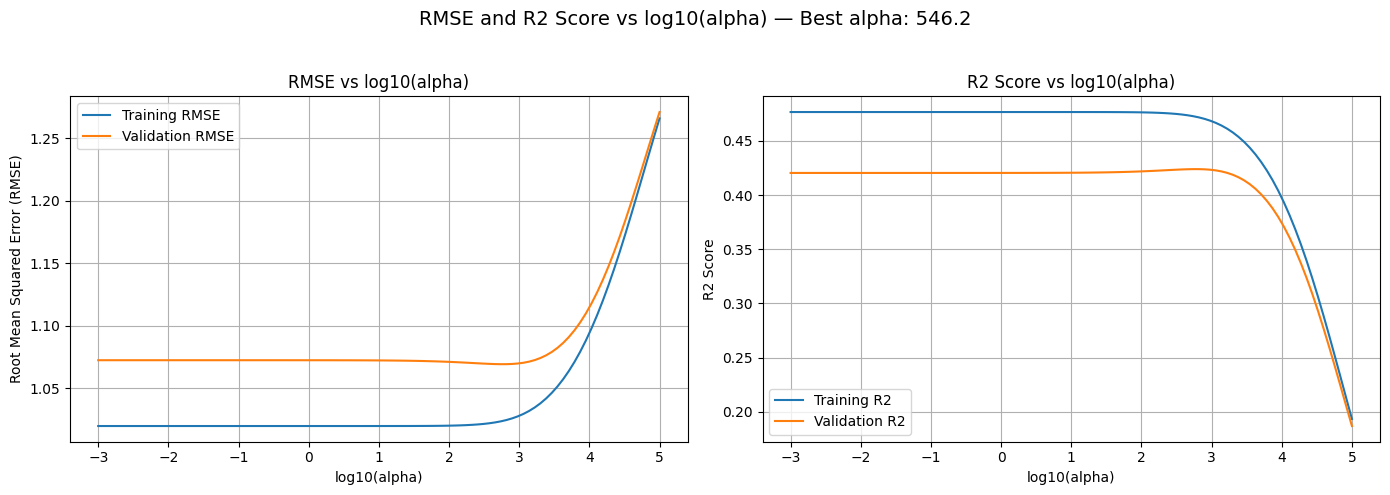

In [11]:
results = grid_search.cv_results_
alphas = results['param_alpha'].data.astype(float)
mean_val_mse = -results['mean_test_neg_mean_squared_error']
mean_train_mse = -results['mean_train_neg_mean_squared_error']
mean_val_rmse = np.sqrt(mean_val_mse)
mean_train_rmse = np.sqrt(mean_train_mse)

mean_val_r2 = results['mean_test_r2']
mean_train_r2 = results['mean_train_r2']

best_alpha = grid_search.best_params_['alpha']

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(np.log10(alphas), mean_train_rmse, label='Training RMSE')
axs[0].plot(np.log10(alphas), mean_val_rmse, label='Validation RMSE')
axs[0].set_xlabel('log10(alpha)')
axs[0].set_ylabel('Root Mean Squared Error (RMSE)')
axs[0].set_title('RMSE vs log10(alpha)')
axs[0].legend()
axs[0].grid(True)


axs[1].plot(np.log10(alphas), mean_train_r2, label='Training R2')
axs[1].plot(np.log10(alphas), mean_val_r2, label='Validation R2')
axs[1].set_xlabel('log10(alpha)')
axs[1].set_ylabel('R2 Score')
axs[1].set_title('R2 Score vs log10(alpha)')
axs[1].legend()
axs[1].grid(True)

fig.suptitle(f'RMSE and R2 Score vs log10(alpha) — Best alpha: {best_alpha:.4g}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()


There are a few things to observe about this result:

- The optimal range of log10(alpha) values seems to be around 3.2, where we get the smallest RMSE.
- The model starts overfitting when log10(alpha) is smaller than 3 as the training error becomes small but we create a larger gap to the validation error.
- The model starts underfitting when log10(alpha) is larger than 4 as training and validation errors agree but the model performs worse than for other alpha values. 


### Model Evaluation after tunning: RMSE and R² Score Calculation

In [12]:
best_ridge = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']

y_val_pred = best_ridge.predict(X_val)
brr_mse_val = mean_squared_error(Y_val, y_val_pred)
brr_rmse_val = np.sqrt(brr_mse_val)
brr_val_r2 = r2_score(Y_val, y_val_pred)

print("Best Ridge Regression Model Performance:")
print(f"Validation MSE: {brr_mse_val}")
print(f"Validation RMSE: {brr_rmse_val}")
print(f"Validation R^2: {brr_val_r2}")
print("Best alpha: {:.2f}".format(best_alpha))


Best Ridge Regression Model Performance:
Validation MSE: 1.1293912897534044
Validation RMSE: 1.0627282294892728
Validation R^2: 0.44152041409476694
Best alpha: 546.23


As we can see, the best alpha is 546.23 with an validation MSE score of 1.129 and RMSE is 1.062.

#### Plot RMSE and R2 Score

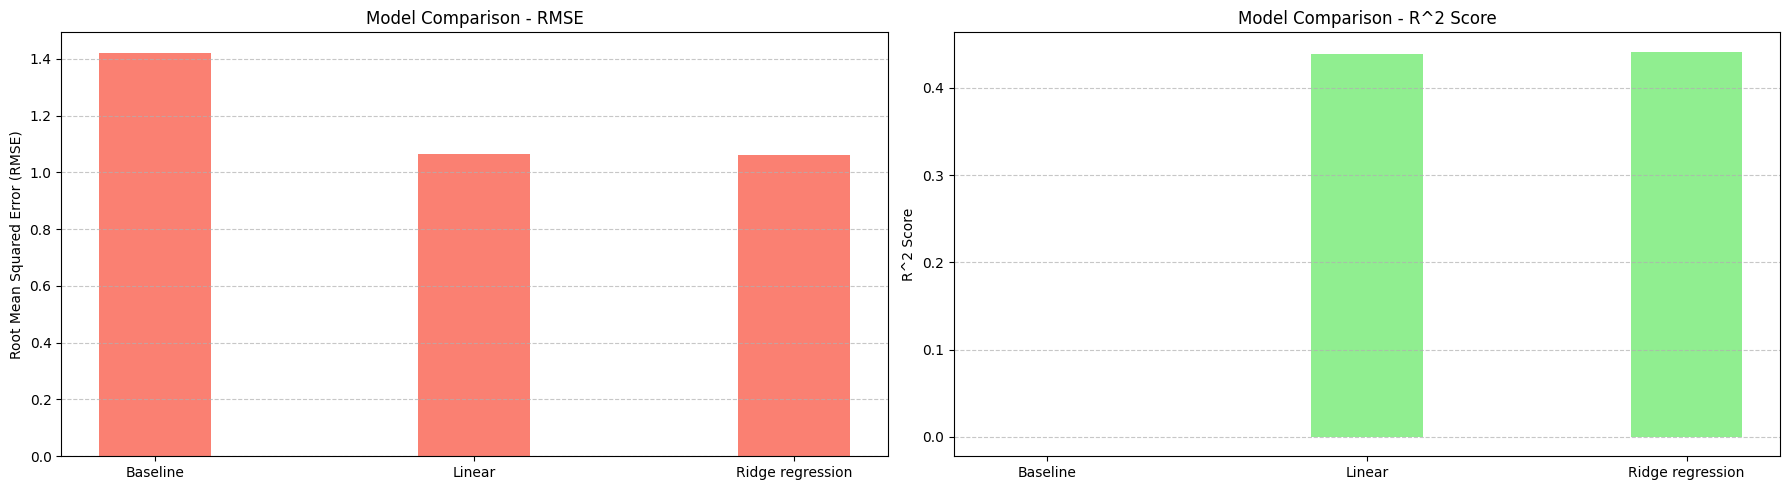

In [13]:
models = ['Baseline', 'Linear', 'Ridge regression']
mse_values = [baseline_mse_val, lr_val_mse, brr_mse_val]
rmse_values = [np.sqrt(mse) for mse in mse_values]

r2_values = [baseline_r2_val, lr_val_r2, brr_val_r2]

x = np.arange(len(models))  
width = 0.35  

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].bar(x, rmse_values, width, color='salmon')
ax[0].set_ylabel('Root Mean Squared Error (RMSE)')
ax[0].set_title('Model Comparison - RMSE')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.7)

# Bar plot for R^1
ax[1].bar(x, r2_values, width, color='lightgreen')
ax[1].set_ylabel('R^2 Score')
ax[1].set_title('Model Comparison - R^2 Score')
ax[1].set_xticks(x)
ax[1].set_xticklabels(models)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


It can be observed that the MSE and R² values are nearly identical in Linear and ridge regression, indicating that using linearization is not helping in reducing rmse values. 
Anyway, linear regression may not be essential here, but I included it for comparison purposes.

## Test Data

Checking and evaluating the test data (which is unseen)

In [14]:
df_test = pd.read_csv('test_data.csv')
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)


X_test_var = selection.transform(X_test)

X_test_scaled = scaler.transform(X_test_var)

y_test_pred = best_ridge.predict(X_test_scaled)
brr_mse_test = mean_squared_error(Y_test, y_test_pred)
brr_rmse_test = np.sqrt(brr_mse_test)

brr_test_r2 = r2_score(Y_test, y_test_pred)
print("Test Set Performance for Rigde Regression:")
print(f"Ridge Regression Test MSE: {brr_mse_test}")
print(f"Ridge Regression Test RMSE: {brr_rmse_test}")
print(f"Ridge Regression Test R^2: {brr_test_r2}")

Shape of X_test: (4235, 2052)
Shape of Y_test: (4235,)
Test Set Performance for Rigde Regression:
Ridge Regression Test MSE: 1.1217064884989507
Ridge Regression Test RMSE: 1.059106457585332
Ridge Regression Test R^2: 0.42414773724842136


In [15]:
baseline_mse_test = MSE(Y_test, y_train_mean)
baseline_rmse_test = np.sqrt(baseline_mse_test)
baseline_r2_test = r2_score(Y_test, np.full_like(Y_test, y_train_mean))

print(f"Baseline Test MSE: {baseline_mse_test}")
print(f"Baseline Test RMSE: {baseline_rmse_test}")
print(f"Baseline Test R^2: {baseline_r2_test}")

lr_test_mse = mean_squared_error(Y_test, lr_model.predict(X_test_scaled))
lr_test_rmse = np.sqrt(lr_test_mse)
lr_test_r2 = r2_score(Y_test, lr_model.predict(X_test_scaled))
print(f"Linear Regression Test MSE: {lr_test_mse}")
print(f"Linear Regression Test RMSE: {lr_test_rmse}")
print(f"Linear Regression Test R^2: {lr_test_r2}")

Baseline Test MSE: 1.947926690559014
Baseline Test RMSE: 1.3956814430804094
Baseline Test R^2: -1.0255743164044873e-05
Linear Regression Test MSE: 1.131018323381148
Linear Regression Test RMSE: 1.0634934524392465
Linear Regression Test R^2: 0.4193673056094299


Plot showing baseline , Linear and Ridge regression on test data

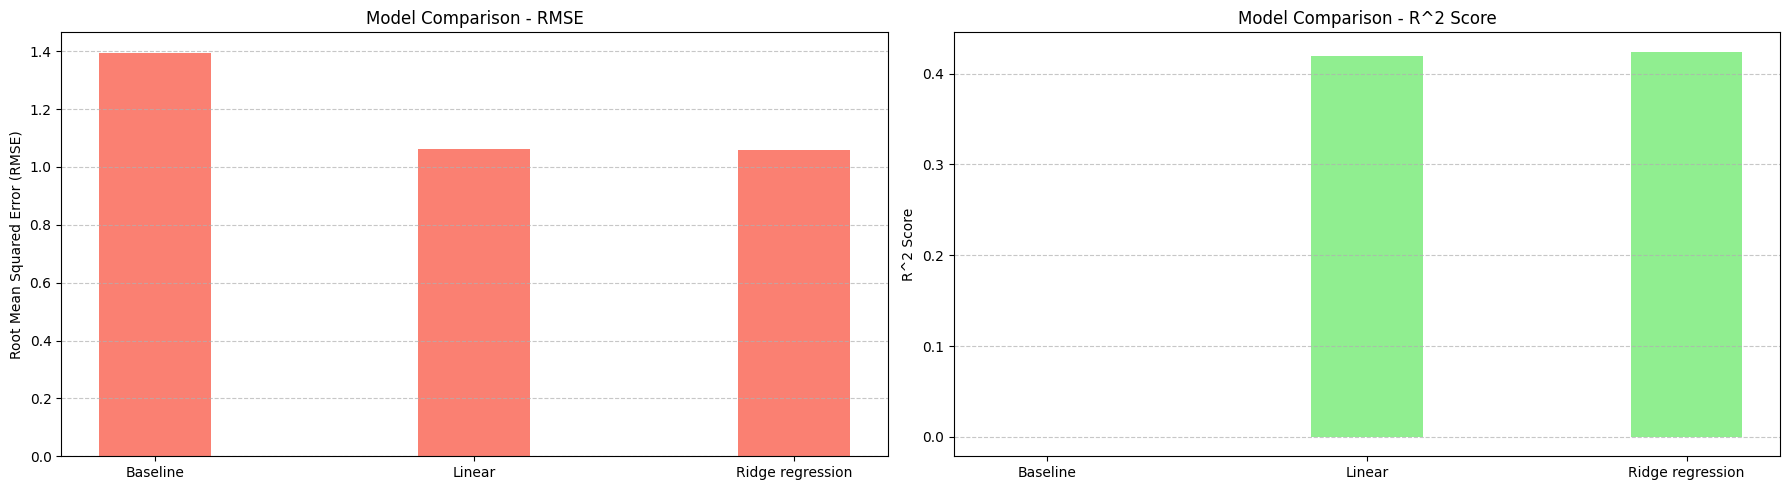

In [16]:
models = ['Baseline', 'Linear', 'Ridge regression']
mse_values = [baseline_mse_test, lr_test_mse, brr_mse_test]
test_rmse_values = [np.sqrt(mse) for mse in mse_values]

test_r2_values = [baseline_r2_test, lr_test_r2, brr_test_r2]

x = np.arange(len(models))  
width = 0.35  

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].bar(x, test_rmse_values, width, color='salmon')
ax[0].set_ylabel('Root Mean Squared Error (RMSE)')
ax[0].set_title('Model Comparison - RMSE')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.7)

# Bar plot for R^2
ax[1].bar(x, test_r2_values, width, color='lightgreen')
ax[1].set_ylabel('R^2 Score')
ax[1].set_title('Model Comparison - R^2 Score')
ax[1].set_xticks(x)
ax[1].set_xticklabels(models)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Observation:

Linear regression and Ridge regression models are giving almost same RMSE values.

#### **Plotting plot of predicted vs actual** 

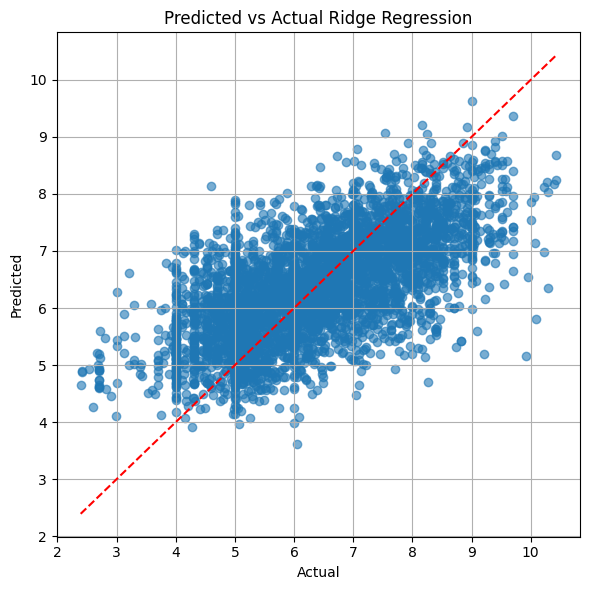

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, y_test_pred, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual Ridge Regression')
plt.grid(True)
plt.tight_layout()
plt.show()

It is observed that the predicted values should ideally align with the red line; however, the deviation indicates that the model is not making highly accurate predictions.

Saving the test RMSE and R-square score for final comparasion in the final task

In [18]:
def save_model_info(model_name, test_accuracy_rmse, r2 ):
    with open("model_info.txt", "a") as file:
        file.write(f"{model_name},{test_accuracy_rmse:.4f}, {r2:.4f}\n")

save_model_info("Baseline_Model", baseline_rmse_test, baseline_r2_test)
save_model_info("Linear_Regression", lr_test_rmse, lr_test_r2)
save_model_info("Ridge_Regression", brr_rmse_test, brr_test_r2)

## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code